In [1]:
import os
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import seaborn as sns

In [2]:
RGAS_J_K_MOL = 8.3144598
TFRZ = 273.15
MIN_VCMAX_FRAC = 0.10
MIN_JMAX_FRAC = 0.10

In [8]:
def fth25_f(hd, se):
    ans = 1.0 + np.exp((-hd + se*(TFRZ + 25.0))/(RGAS_J_K_MOL*(TFRZ + 25.0)))
    return ans


def fth_f(tl, hd, se, scaleFactor):
    ans = scaleFactor/(1.0 + np.exp((-hd+se*tl)/(RGAS_J_K_MOL*tl)))
    return ans


def ft1_f(tl, ha):
    ans = np.exp(ha/(RGAS_J_K_MOL*(TFRZ + 25.0))*(1.0 - (TFRZ+25.0)/tl))
    return ans

def calc_clm_jmaxse(t10):
    if t10 < 11.0:
        t10 = 11.0
    if t10 > 35.0:
        t10 = 35.0
        
    jmaxse = (659.70 - 0.75 * t10)
    return jmaxse
    
def calc_clm_vcmaxse(t10):
    if t10 < 11.0:
        t10 = 11.0
    if t10 > 35.0:
        t10 = 35.0
        
    vcmaxse = (668.39 - 1.07 * t10)
    return vcmaxse

def get_vcmax_jmax(veg_tempk, vcmaxhd_fates, vcmaxse_fates, vcmaxha_fates,
                   jmaxhd_fates, jmaxse_fates, jmaxha_fates, jmax25top_fates,
                   vcmax25top_fates):

    vcmaxc_fates = fth25_f(vcmaxhd_fates, vcmaxse_fates)
    jmaxc_fates = fth25_f(jmaxhd_fates, jmaxse_fates)
    
    vcmax25_fates = vcmax25top_fates * nscaler * dayl_factor_local
    
    jmax25_fates = jmax25top_fates * nscaler * dayl_factor_local
    
    if c3:
        vcmax_fates = vcmax25_fates * ft1_f(veg_tempk, vcmaxha_fates) * fth_f(veg_tempk, vcmaxhd_fates, vcmaxse_fates, vcmaxc_fates)
    
    jmax_fates = jmax25_fates * ft1_f(veg_tempk, jmaxha_fates) * fth_f(veg_tempk, jmaxhd_fates, jmaxse_fates, jmaxc_fates)
    
    vcmax_fates = np.max([MIN_VCMAX_FRAC*vcmax25top_fates, vcmax_fates])
    jmax_fates = np.max([MIN_JMAX_FRAC*jmax25top_fates, jmax_fates])

    return vcmax_fates, jmax_fates

def calc_topt(hd, ha, se):
    return hd/(se - RGAS_J_K_MOL*np.log(ha/(hd - ha)))


In [10]:
def get_values(fates_param, clm_param, type):
    vcmaxhd_fates = fates_param['fates_leaf_vcmaxhd'].values[pft_index]
    vcmaxse_fates = fates_param['fates_leaf_vcmaxse'].values[pft_index]
    vcmaxha_fates = fates_param['fates_leaf_vcmaxha'].values[pft_index]
    
    jmaxhd_fates = fates_param['fates_leaf_jmaxhd'].values[pft_index]
    jmaxse_fates = fates_param['fates_leaf_jmaxse'].values[pft_index]
    jmaxha_fates = fates_param['fates_leaf_jmaxha'].values[pft_index]
    
    vcmax25top_fates = fates_param['fates_leaf_vcmax25top'].values[0, pft_index]
    
    jmax25top_fates = 1.67*vcmax25top_fates

    vcmaxhd_clm = clm_param['vcmaxhd'].values
    vcmaxha_clm = clm_param['vcmaxha'].values
    vcmaxse_sf = clm_param['vcmaxse_sf'].values
    
    jmaxhd_clm = clm_param['jmaxhd'].values
    jmaxha_clm = clm_param['jmaxha'].values
    jmaxse_sf = clm_param['jmaxse_sf'].values
    
    act25_clm = clm_param['act25'].values
    fnr_clm = clm_param['fnr'].values
    
    flnr_clm = clm_param['flnr'].values[4]
    leafcn = clm_param['leafcn'].values[4]
    slatop = clm_param['slatop'].values[4]
    
    lnc = 1.0 / (slatop * leafcn)


    veg_tempk = TFRZ + np.arange(-10, 35, 1)
    vcmax_clm = np.zeros(len(veg_tempk))
    jmax_clm = np.zeros(len(veg_tempk))
    
    vcmax_fates = np.zeros(len(veg_tempk))
    jmax_fates = np.zeros(len(veg_tempk))

    for i, temp in enumerate(veg_tempk):
        
        v, j = get_vcmax_jmax(temp, vcmaxhd_fates, vcmaxse_fates, vcmaxha_fates,
                              jmaxhd_fates, jmaxse_fates, jmaxha_fates, 
                              jmax25top_fates, vcmax25top_fates)
        vcmax_fates[i] = v
        jmax_fates[i] = j

    for i, temp in enumerate(veg_tempk):
        vcmaxse_clm = calc_clm_vcmaxse(temp)*vcmaxse_sf
        jmaxse_clm = calc_clm_jmaxse(temp)*jmaxse_sf
        vcmax25top_clm = lnc * flnr_clm * fnr_clm * act25_clm * dayl_factor_local
        
        v, j = get_vcmax_jmax(temp, vcmaxhd_clm, vcmaxse_clm, vcmaxha_clm,
                              jmaxhd_clm, jmaxse_clm, jmaxha_clm,
                              jmax25top_fates, vcmax25top_clm)
        vcmax_clm[i] = v
        jmax_clm[i] = j

    topt_vcmax_fates = calc_topt(vcmaxhd_fates, vcmaxha_fates, vcmaxse_fates)
    topt_vcmax_clm = calc_topt(vcmaxhd_clm, vcmaxha_clm, vcmaxse_clm)
    topt_jmax_fates = calc_topt(jmaxhd_fates, jmaxha_fates, jmaxse_fates)
    topt_jmax_clm = calc_topt(jmaxhd_clm, jmaxha_clm, jmaxse_clm)

    df = pd.DataFrame({
        'vcmax_fates': vcmax_fates,
        'vcmax_clm': vcmax_clm,
        'jmax_fates': jmax_fates,
        'jmax_clm': jmax_clm,
        'vegtempk': veg_tempk
    })

    df['type'] = type
    df['topt_vcmax_fates'] = topt_vcmax_fates
    df['topt_vcmax_clm'] = topt_vcmax_clm
    df['topt_jmax_fates'] = topt_jmax_fates
    df['topt_jmax_clm'] = topt_jmax_clm

    return df

In [5]:
param_dir = '/glade/work/afoster/FATES_calibration/parameter_files'
fates_param_file = os.path.join(param_dir, 'fates_params_default_sci.1.81.1_api.38.0.0_crops_vai.nc')
clm_param_file = os.path.join(param_dir, 'ctsm60_params.c241017.nc')

fates_param_default = xr.open_dataset(fates_param_file)
clm_param_default = xr.open_dataset(clm_param_file)

clm_param_minvcmaxha = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0364.nc'))
clm_param_maxvcmaxha = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0365.nc'))
fates_param_minvcmaxha = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_119.nc'))
fates_param_maxvcmaxha = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_120.nc'))

clm_param_minvcmaxhd = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0378.nc'))
clm_param_maxvcmaxhd = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0379.nc'))
fates_param_minvcmaxhd = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_121.nc'))
fates_param_maxvcmaxhd = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_122.nc'))

clm_param_minvcmaxse = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0386.nc'))
clm_param_maxvcmaxse = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0387.nc'))
fates_param_minvcmaxse = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_123.nc'))
fates_param_maxvcmaxse = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_124.nc'))

########

clm_param_minjmaxha = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0366.nc'))
clm_param_maxjmaxha = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0367.nc'))
fates_param_minjmaxha = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_093.nc'))
fates_param_maxjmaxha = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_094.nc'))

clm_param_minjmaxhd = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0380.nc'))
clm_param_maxjmaxhd = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0381.nc'))
fates_param_minjmaxhd = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_095.nc'))
fates_param_maxjmaxhd = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_096.nc'))

clm_param_minjmaxse = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0388.nc'))
clm_param_maxjmaxse = xr.open_dataset(os.path.join(param_dir, 'clm_oaat', 'CLM6SPoaat0389.nc'))
fates_param_minjmaxse = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_097.nc'))
fates_param_maxjmaxse = xr.open_dataset(os.path.join(param_dir, 'fates_oaat', 'FATES_OAAT_098.nc'))

In [11]:
nscaler = 1.0
dayl_factor_local = 1.0

In [12]:
pft_index = 0
c3 = True

In [16]:
default_df = get_values(fates_param_default, clm_param_default, 'default')

minvcmaxha= get_values(fates_param_minvcmaxha, clm_param_minvcmaxha, 'vcmaxha_min')
maxvcmaxha = get_values(fates_param_maxvcmaxha, clm_param_maxvcmaxha, 'vcmaxha_max')

minvcmaxhd = get_values(fates_param_minvcmaxhd, clm_param_minvcmaxhd, 'vcmaxhd_min')
maxvcmaxhd= get_values(fates_param_maxvcmaxhd, clm_param_maxvcmaxhd, 'vcmaxhd_max')

minvcmaxse = get_values(fates_param_minvcmaxse, clm_param_minvcmaxse, 'vcmaxse_min')
maxvcmaxse = get_values(fates_param_maxvcmaxse, clm_param_maxvcmaxse, 'vcmaxse_max')

####

minjmaxha = get_values(fates_param_minjmaxha, clm_param_minjmaxha, 'jmaxha_min')
maxjmaxha = get_values(fates_param_maxjmaxha, clm_param_maxjmaxha, 'jmaxha_max')

minjmaxhd = get_values(fates_param_minjmaxhd, clm_param_minjmaxhd, 'jmaxhd_min')
maxjmaxhd = get_values(fates_param_maxjmaxhd, clm_param_maxjmaxhd, 'jmaxhd_max')

minjmaxse = get_values(fates_param_minjmaxse, clm_param_minjmaxse, 'jmaxse_min')
maxjmaxse = get_values(fates_param_maxjmaxse, clm_param_maxjmaxse, 'jmaxse_max')

df_vcmax = pd.concat([default_df, minvcmaxha, maxvcmaxha, minvcmaxhd, maxvcmaxhd,
               minvcmaxse, maxvcmaxse])

df_jmax = pd.concat([default_df, minjmaxha, maxjmaxha, minjmaxhd, 
               maxjmaxhd, minjmaxse, maxjmaxse])

In [34]:
vcmax_topt = df_vcmax[['type', 'topt_vcmax_fates', 'topt_vcmax_clm']].drop_duplicates().melt(id_vars=['type'])
vcmax_topt['model'] = [str(s).split('_')[2] for s in vcmax_topt.variable]
vcmax_topt['topt'] = vcmax_topt.value - 273.15

jmax_topt = df_jmax[['type', 'topt_jmax_fates', 'topt_jmax_clm']].drop_duplicates().melt(id_vars=['type'])
jmax_topt['model'] = [str(s).split('_')[2] for s in jmax_topt.variable]
jmax_topt['topt'] = jmax_topt.value - 273.15

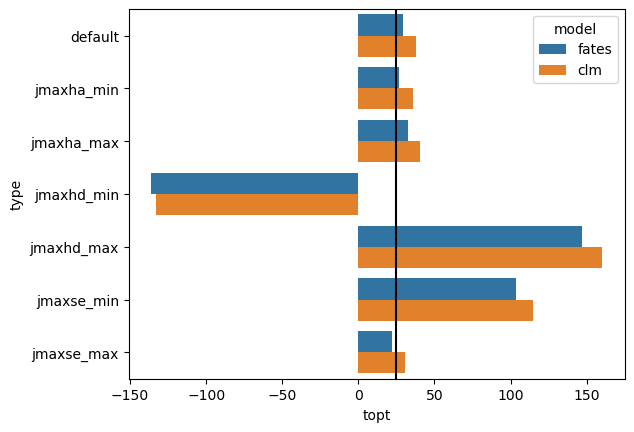

In [39]:
sns.barplot(data=jmax_topt, y='type', x='topt', hue='model')
plt.axvline(25, c='black')

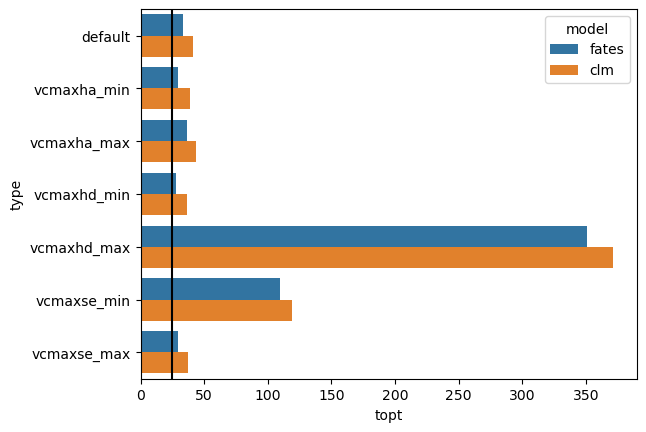

In [40]:
sns.barplot(data=vcmax_topt, y='type', x='topt', hue='model')
plt.axvline(25, c='black')

In [41]:
df_vcmax['variable'] = 'vcmax'
df_vcmax = df_vcmax.drop(columns=['jmax_clm', 'jmax_fates'])
df_vcmax = df_vcmax.melt(id_vars=['vegtempk', 'type', 'variable'], var_name='model')
df_vcmax['model'] = [str(s).replace('vcmax_', '') for s in df_vcmax.model]
df_vcmax['parameter'] = [str(s).split('_')[0] for s in df_vcmax.type]
df_vcmax['type'] = [
    str(s).split('_')[1] if len(str(s).split('_')) > 1 else str(s).split('_')[0]
    for s in df_vcmax.type
]

diff_df_vcmax = df_vcmax[df_vcmax.parameter != 'default'].pivot(index=['vegtempk', 'model', 'parameter'], 
                                                        columns='type', values='value').reset_index()
diff_df_vcmax['diff'] = diff_df_vcmax['max'] - diff_df_vcmax['min']


df_jmax['variable'] = 'jmax'
df_jmax = df_jmax.drop(columns=['vcmax_clm', 'vcmax_fates'])
df_jmax = df_jmax.melt(id_vars=['vegtempk', 'type', 'variable'], var_name='model')
df_jmax['model'] = [str(s).replace('jmax_', '') for s in df_jmax.model]

df_jmax['parameter'] = [str(s).split('_')[0] for s in df_jmax.type]
df_jmax['type'] = [
    str(s).split('_')[1] if len(str(s).split('_')) > 1 else str(s).split('_')[0]
    for s in df_jmax.type
]

diff_df_jmax = df_jmax[df_jmax.parameter != 'default'].pivot(index=['vegtempk', 'model', 'parameter'], 
                                                        columns='type', values='value').reset_index()
diff_df_jmax['diff'] = diff_df_jmax['max'] - diff_df_jmax['min']

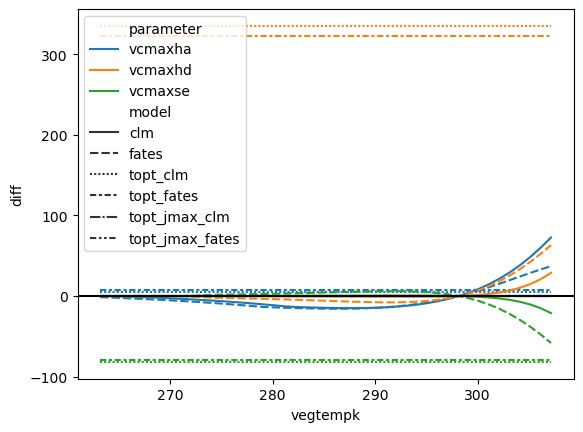

In [42]:
sns.lineplot(data=diff_df_vcmax,
             x='vegtempk', y='diff',
             hue='parameter', style='model')
plt.axhline(c='k')

In [ ]:
sns.lineplot(data=diff_df_jmax,
             x='vegtempk', y='diff',
             hue='parameter', style='model')
plt.axhline(c='k')

In [ ]:
sns.lineplot(data=df_jmax[df_jmax.parameter == 'jmaxha'],
             x='vegtempk', y='value',
             hue='type', style='model')

,vegtempk,type,variable,model,value,parameter
0,263.15,default,vcmax,fates,5.000000,default
1,264.15,default,vcmax,fates,5.000000,default
2,265.15,default,vcmax,fates,5.000000,default
3,266.15,default,vcmax,fates,5.000000,default
4,267.15,default,vcmax,fates,5.000000,default
...,...,...,...,...,...,...
1885,303.15,max,vcmax,topt_jmax_clm,311.243177,vcmaxse
1886,304.15,max,vcmax,topt_jmax_clm,311.243177,vcmaxse
1887,305.15,max,vcmax,topt_jmax_clm,311.243177,vcmaxse
1888,306.15,max,vcmax,topt_jmax_clm,311.243177,vcmaxse
